In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"/kaggle/input/datasets/nasimetemadi/bank-marketing/bank.csv", sep=";")

# Objective

This analysis explores behavioral drivers of subscription outcomes in a bank marketing campaign dataset. 

Results indicate that prior customer relationship history, particularly previous campaign success, is the strongest predictor of conversion, while demographic factors such as age, education, and occupation shape baseline likelihood. 

Numeric campaign metrics show limited influence, suggesting that customer characteristics play a larger role than campaign mechanics in determining engagement outcomes.

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [4]:
df.shape

(4521, 17)

In [5]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

Duration : Length of the phone call (in seconds)
y: Did the client subscribe to the term deposit after the campaign?
previous : number of earlier contacts
pdays : days since last contact

In [6]:
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [7]:
df.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00,4521.00
mean,41.17,1422.66,15.92,263.96,2.79,39.77,0.54
std,10.58,3009.64,8.25,259.86,3.11,100.12,1.69
min,19.00,-3313.00,1.00,4.00,1.00,-1.00,0.00
25%,33.00,69.00,9.00,104.00,1.00,-1.00,0.00
50%,39.00,444.00,16.00,185.00,2.00,-1.00,0.00
75%,49.00,1480.00,21.00,329.00,3.00,-1.00,0.00
max,87.00,71188.00,31.00,3025.00,50.00,871.00,25.00


# Target variable - predict y

In [8]:
df['y'].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

In [9]:
df['y_binary'] = df['y'].map({'yes': 1, 'no': 0})

df['y_binary'] = df['y_binary'].astype('boolean')

<Axes: >

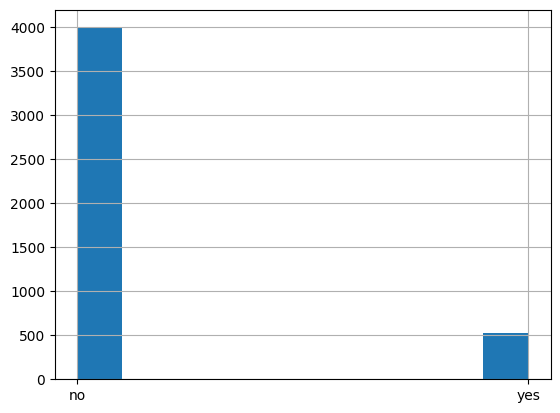

In [10]:
df['y'].hist()

In [11]:
df['y_binary'].skew().round(2)

np.float64(2.41)

Positive skew means that most values are 0, with fewer 1s - most customers did not subscribe

In [12]:
df['y_binary'].mean().round(2)

np.float64(0.12)

12% subscribed

# Correlation matrix

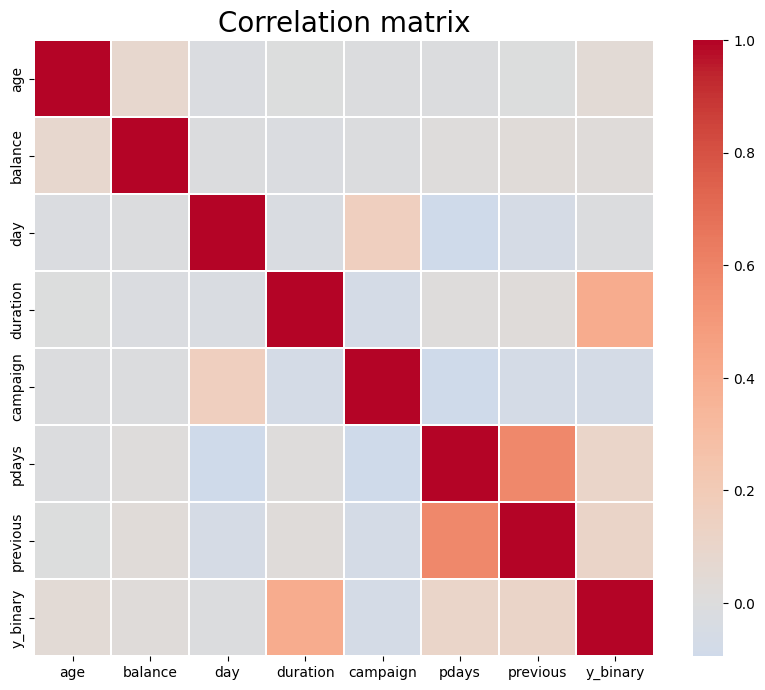

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation matrix", fontsize=20)
plt.show()

Correlation analysis revealed minimal linear relationships across numeric features, with call duration showing the strongest association with subscription outcome. BUT it happens after the call starts.

So for behavioral understanding → OK

For predictive modeling → risky (data leakage)

Aside from structural relationships between historical contact variables, the weak correlations suggest that behavioral differences are primarily driven by categorical customer characteristics rather than numeric metrics

# Age

Bucket	Behavioral meaning

18–29	Early career / low savings

30–39	Career building

40–49	Stable earners

50–59	Pre-retirement planning

60+	Retirement focus

In [14]:
df['age_band'] = pd.cut(df['age'],bins=[18, 30, 40, 50, 60, df['age'].max()],labels=['early_career','career_building','stable_earners','pre_retirement','retirement'],right=False)

Subscription rate by age group

In [15]:
age_check = df.groupby('age_band').agg(
    sub_rate=('y_binary', 'mean'),
    count=('y_binary', 'size')
).sort_values(by='sub_rate', ascending=False)

age_check.round(2)

/tmp/ipykernel_17/1092588383.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_check = df.groupby('age_band').agg(


,sub_rate,count
age_band,,
retirement,0.31,173
early_career,0.15,482
career_building,0.1,1808
stable_earners,0.1,1203
pre_retirement,0.1,854


Retirement-aged clients subscribe much more often - 31%, but also, they are the smallest group of clients.

Retirement clients appear more likely to subscribe, but results should be interpreted cautiously due to smaller sample size.

Marketing messages resonate more with older clients seeking stability

# Job

In [16]:
job_check = df.groupby('job').agg(
    sub_rate=('y_binary', 'mean'),
    count=('y_binary', 'size')
).sort_values(by='sub_rate', ascending=False)

job_check.round(2)

,sub_rate,count
job,,
retired,0.23,230
student,0.23,84
unknown,0.18,38
management,0.14,969
housemaid,0.12,112
admin.,0.12,478
self-employed,0.11,183
technician,0.11,768
unemployed,0.1,128


Retired clients show consistently higher subscription rates, while student and unknown categories may require cautious interpretation due to smaller sample sizes.

# Education

In [17]:
edu_check = df.groupby('education').agg(
    sub_rate=('y_binary', 'mean'),
    count=('y_binary', 'size')
).sort_values(by='sub_rate', ascending=False)

edu_check.round(2)

,sub_rate,count
education,,
tertiary,0.14,1350
secondary,0.11,2306
unknown,0.1,187
primary,0.09,678


We can see a clear gradient, higher education → higher subscription rate.

Tertiary-educated clients exhibit higher relative engagement compared to primary-educated groups

# Marital Status

In [18]:
mar_check = df.groupby('marital').agg(
    sub_rate=('y_binary', 'mean'),
    count=('y_binary', 'size')
).sort_values(by='sub_rate', ascending=False)

mar_check.round(2)

,sub_rate,count
marital,,
divorced,0.15,528
single,0.14,1196
married,0.1,2797


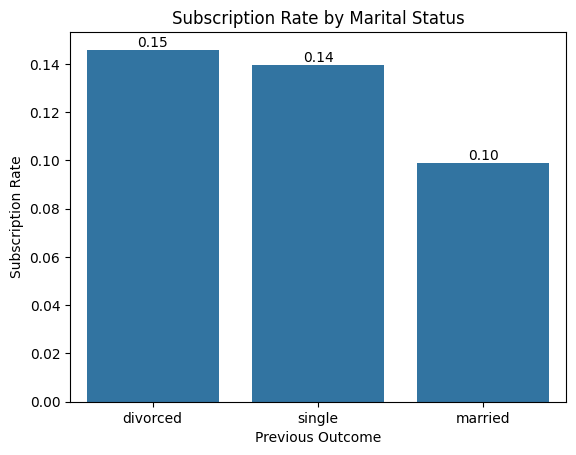

In [19]:
ax = sns.barplot(data=mar_check, x='marital', y='sub_rate')

# add labels on bars
ax.bar_label(ax.containers[0], fmt="%.2f")

ax.set_title("Subscription Rate by Marital Status")
ax.set_ylabel("Subscription Rate")
ax.set_xlabel("Previous Outcome")

plt.show()

Previous campaign outcome

In [20]:
poutcome_check = df.groupby('poutcome').agg(
    sub_rate=('y_binary', 'mean'),
    count=('y_binary', 'size')
).sort_values(by='sub_rate', ascending=False)

poutcome_check.round(2)

,sub_rate,count
poutcome,,
success,0.64,129
other,0.19,197
failure,0.13,490
unknown,0.09,3705


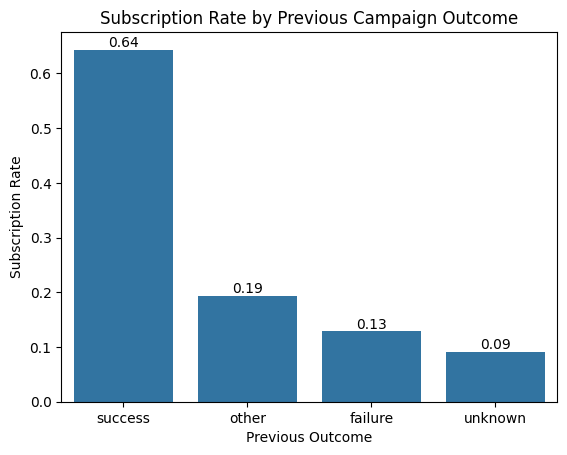

In [21]:
ax = sns.barplot(data=poutcome_check, x='poutcome', y='sub_rate')

# add labels on bars
ax.bar_label(ax.containers[0], fmt="%.2f")

ax.set_title("Subscription Rate by Previous Campaign Outcome")
ax.set_ylabel("Subscription Rate")
ax.set_xlabel("Previous Outcome")

plt.show()

Customers who previously had a successful campaign are far more likely to subscribe again, 6x increase

Prior campaign success is strongly associated with higher subscription rates, although the segment represents a smaller subset of customers

So far, the strongest predictors:

- retired
- tertiary education
- single/divorced
- previous successful campaign


These describe: customer history and socioeconomic profile. 

# Age band vs Previous Campaign Outcome

In [22]:
check3 = df.groupby(['age_band','poutcome']).agg(
    sub_rate=('y_binary', 'mean'),
    count=('y_binary', 'size')
).sort_values(by='sub_rate', ascending=False)

check3.round(2)

/tmp/ipykernel_17/3335266863.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  check3 = df.groupby(['age_band','poutcome']).agg(


sub_rate  count
age_band        poutcome                 
early_career    success       0.81     16
stable_earners  success       0.67     27
pre_retirement  success       0.64     22
retirement      success       0.61     18
career_building success       0.59     46
retirement      unknown       0.29    122
                failure       0.26     27
pre_retirement  other         0.26     31
early_career    other         0.24     29
stable_earners  other         0.17     53
career_building other         0.17     78
retirement      other         0.17      6
pre_retirement  failure       0.16     89
early_career    failure       0.15     40
                unknown       0.12    397
career_building failure       0.11    219
stable_earners  failure        0.1    115
                unknown       0.08   1008
career_building unknown       0.08   1465
pre_retirement  unknown       0.07    712

Previous success dominates everything, early-career customers with prior success exhibit very high conversion rates, although the segment size is limited.

But the percentages show that customer relationship history drives success. 

# Contact

In [23]:
check4 = df.groupby('contact').agg(
    sub_rate=('y_binary', 'mean'),
    count=('y_binary', 'size')
).sort_values(by='sub_rate', ascending=False)

check4.round(2)

,sub_rate,count
contact,,
telephone,0.15,301
cellular,0.14,2896
unknown,0.05,1324


Contact method shows minimal difference in subscription performance between telephone and cellular channels. 

owever, records with unknown contact type exhibit substantially lower conversion rates, suggesting that data completeness and targeting quality may influence campaign effectiveness.

# EDA Summary

- Customer relationship history is the strongest behavioral driver.
Previous campaign success (poutcome = success) shows substantially higher subscription rates compared to all other groups, indicating that prior positive engagement strongly influences future responses.

- Demographic factors shape baseline likelihood.
Higher subscription rates were observed among retired clients, tertiary-educated customers, and certain professional job categories, while blue-collar segments showed comparatively lower engagement.

- Life stage effects are visible through engineered age bands.
Retirement-age customers demonstrated higher conversion rates even without prior campaign success, suggesting differences in financial priorities across age groups.

- Contact channel shows limited impact.
Telephone and cellular contact methods exhibit similar performance, while records with unknown contact type display significantly lower conversion rates, likely reflecting lower data quality or targeting precision.

- Numeric correlations are generally weak.
Aside from call duration — which strongly correlates with the outcome but represents post-contact behavior — most numeric variables show limited linear association with subscription results. 
This suggests that categorical customer characteristics explain behavior more effectively than numeric metrics.

- Overall Insight:
Subscription outcomes appear to be driven primarily by customer relationship history and demographic characteristics rather than campaign mechanics alone.

# ML - Which factors increase likelihood of client's decision?

Model choice: Logistic Regression, because:

- It predicts probabilities between 0 and 1

- Coefficients are interpretable

- Perfect for behavioral analysis

Step 1 — Define target (y) and features (X)

In [24]:
y = df['y_binary']

X = df.drop(columns=['y', 'y_binary', 'duration'])

Step 2 — One-hot encode categorical features

In [25]:
X_encoded = pd.get_dummies(X, drop_first=True)

Step 3 — Train/test split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Step 4 — Fit logistic regression (interpretable baseline model)

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

Step 5 — Evaluate

In [28]:
from sklearn.metrics import classification_report, confusion_matrix

pred = model.predict(X_test)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))

[[789  12]
 [ 88  16]]
              precision    recall  f1-score   support

         0.0      0.900     0.985     0.940       801
         1.0      0.571     0.154     0.242       104

    accuracy                          0.890       905
   macro avg      0.736     0.569     0.591       905
weighted avg      0.862     0.890     0.860       905



Step 6 — Which factors contribute most? (coefficient table)

In [29]:
coef = pd.Series(model.coef_[0], index=X_encoded.columns).sort_values()

top_negative = coef.head(10)
top_positive = coef.tail(10)

top_negative, top_positive

(contact_unknown            -0.847781
 month_jan                  -0.774170
 month_nov                  -0.634431
 loan_yes                   -0.537366
 month_may                  -0.530185
 marital_married            -0.505787
 poutcome_unknown           -0.470644
 age_band_career_building   -0.444525
 month_jul                  -0.399536
 job_unemployed             -0.332946
 dtype: float64,
 month_dec              0.186305
 default_yes            0.190211
 job_retired            0.190372
 education_secondary    0.212071
 job_student            0.231979
 age_band_retirement    0.242862
 month_jun              0.256039
 month_mar              0.614845
 month_oct              1.146742
 poutcome_success       2.012811
 dtype: float64)

Biggest Positive Drivers (most influential)

- poutcome_success (+2.08) - customers who previously responded successfully are far more likely to subscribe again

- month_oct, month_mar- campaign timing influences responsiveness

- age_band_retirement, job_retired, job_student - demographics still matter


Strong Negative Drivers

- contact_unknown (−0.91) - missing or unclear contact information reduces success dramatically.


- marital_married (−0.56) - married clients show lower uptake relative to baseline.


- loan_yes - customers with active loans appear less likely to subscribe.


- poutcome_unknown -no prior relationship = much lower success

In [30]:
coef_sorted = coef.sort_values()

/tmp/ipykernel_17/223893315.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


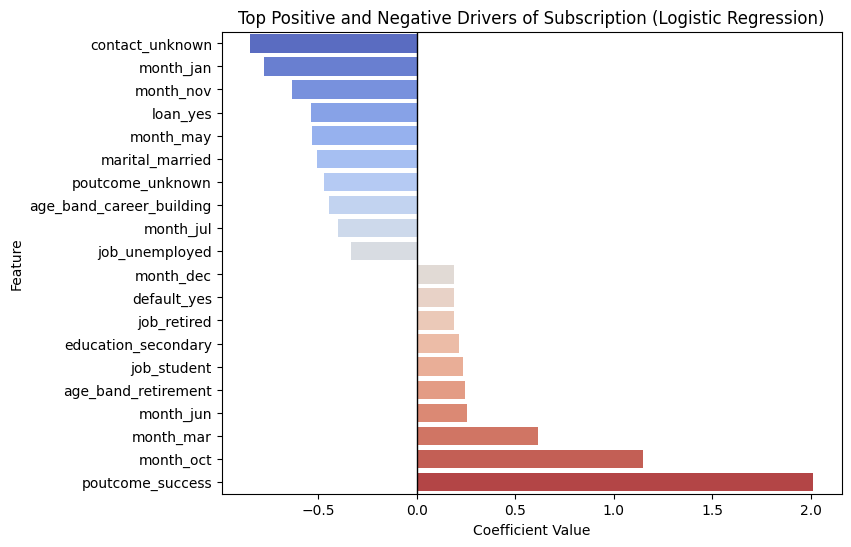

In [31]:
top_features = pd.concat([coef_sorted.head(10), coef_sorted.tail(10)])

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_features.values,
    y=top_features.index,
    palette="coolwarm"
)

plt.axvline(0, color='black', linewidth=1)
plt.title("Top Positive and Negative Drivers of Subscription (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

# Project Conclusion

This project explored customer subscription behavior using the Bank Marketing dataset with the goal of identifying interpretable drivers of campaign success and supporting smarter targeting decisions.

Behavioral exploratory analysis revealed that prior campaign outcomes were the strongest indicator of future subscription likelihood, suggesting that customer receptiveness and historical engagement play a larger role than purely demographic characteristics. While demographic variables such as retirement status, education level, and job category showed meaningful patterns, most numeric variables displayed weak linear relationships with the target outcome. 

Call duration was intentionally excluded from modeling due to data leakage risk, ensuring that predictions relied only on information available before a marketing contact occurs.

An interpretable logistic regression model was developed to quantify how these behavioral and demographic signals influence subscription probability. The resulting coefficients aligned closely with insights from EDA, reinforcing confidence in the analytical workflow. Previous campaign success emerged as the dominant predictor, indicating that effective targeting strategies may benefit from leveraging historical engagement data rather than relying solely on static customer attributes.

Rather than optimizing for raw accuracy, the model is best understood as a prioritization tool that ranks customers by likelihood to subscribe. 

This framing highlights a practical application: marketing teams could focus outreach on higher-probability segments to improve conversion efficiency and reduce unnecessary contact attempts.